In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

# 06 — Unconventional Axes: Material Sweeps & Custom Parameter Maps

One of the most powerful features of this library is that **any** `ProcessParameters` field
or **any** `Material` property can serve as a sweep axis. This notebook demonstrates two
advanced use cases: a scan speed vs absorptivity map (exploring material/wavelength effects),
and a thermal conductivity vs laser power map (exploring alloy selection).

---

## Section 1 — Imports and Context

The key architectural insight: because `Material` properties are now NumPy arrays, you can
pass a *vector* of absorptivity values into `Material(...)` and pair it with a matching
`scan_speed` vector in `ProcessParameters`. The `MeltPool` and `PrintabilitySpace` will
broadcast correctly across both.

When the sweep axis is a **Material property** (not a `ProcessParameters` field), the
`plot_2d()` bridge cannot be used directly — it only resolves `ProcessParameters` names.
Instead, we extract `space.defect_map` and plot it manually with Matplotlib, giving full
control over axis labels and aesthetics.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter

from lpbf_map import Material, ProcessParameters, MeltPool, PrintabilitySpace
from lpbf_map.defects import (
    DefectSuite,
    LackOfFusionCriterion,
    BallingPlateauRayleighCriterion,
    KeyholeGanCriterion,
)

# Shared colour palette for defect maps across all sections
COLORS = {
    0: '#140b34',  # Safe Zone
    1: '#f6d746',  # Balling
    2: '#e55c30',  # Lack of Fusion
    3: '#84206b',  # Keyhole
}


def build_standard_suite():
    """Helper: returns a DefectSuite with the standard three criteria."""
    suite = DefectSuite()
    suite.add(1, BallingPlateauRayleighCriterion())
    suite.add(2, LackOfFusionCriterion())
    suite.add(3, KeyholeGanCriterion())
    return suite


print('Imports complete.')

Imports complete.


---

## Section 2 — Scan Speed vs Absorptivity Map (Ti-6Al-4V)

**Goal:** How does the printability window shift as absorptivity changes (simulating different
surface conditions or powder morphologies)?

Real-world absorptivity for Ti-6Al-4V at 1064 nm spans roughly 0.30–0.80 depending on
surface oxidation, powder particle size, and degree of sintering. This map reveals how
sensitive the safe zone boundaries are to that uncertainty.

**Broadcasting strategy:**
- `absorptivity` is a **row vector** `(1, 30)` — varies across the columns.
- `scan_speed` is a **column vector** `(30, 1)` — varies down the rows.
- NumPy broadcast rules expand both to `(30, 30)` during physics evaluation.

In [3]:
# Row vector: absorptivity varies across columns  (dimensionless)
absorptivities = np.linspace(0.3, 0.8, 30)[np.newaxis, :]   # shape: (1, 30)

# Column vector: scan_speed varies down rows         [m/s]
scan_speeds = np.linspace(0.3, 2.5, 30)[:, np.newaxis]       # shape: (30, 1)

# Create a Ti64-like material with an array absorptivity
mat = Material(
    name='Ti64_absorptivity_sweep',
    density=4250,
    specific_heat=745,
    thermal_conductivity=38,
    melting_temperature=1877,
    boiling_temperature=3560,
    absorptivity=absorptivities    # <-- array!
)

params = ProcessParameters(
    laser_power=200.0,           # fixed laser power [W]
    scan_speed=scan_speeds,      # swept down rows   [m/s]
    beam_radius=40e-6,           # [m]
    hatch_spacing=80e-6,         # [m]
    layer_thickness=30e-6        # [m]
)

print(f'Absorptivity array shape : {mat.absorptivity.shape}')   # -> (1, 30)
print(f'ProcessParameters shape  : {params.shape}')             # -> (30, 1)

pool = MeltPool(mat, params)
suite = build_standard_suite()
space = DefectSuite  # placeholder — replaced below

space = PrintabilitySpace(pool, suite)
space.evaluate()

print(f'Defect map shape         : {space.defect_map.shape}')   # -> (30, 30)

Absorptivity array shape : (1, 30)
ProcessParameters shape  : (30, 1)
Defect map shape         : (30, 30)


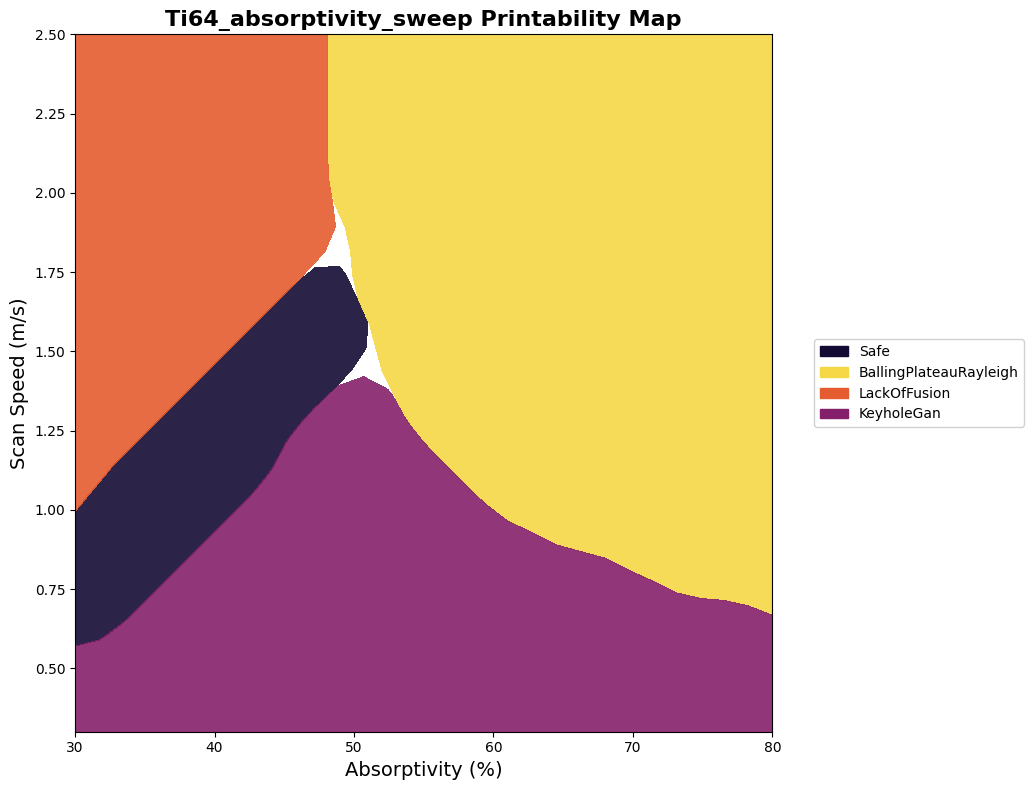

In [4]:
fig, ax = space.plot_2d(x_axis='absorptivity', y_axis='scan_speed', save_path='plots/ti64_absorptivity_sweep.png')

---

## Section 3 — Thermal Conductivity vs Laser Power Map (Alloy Design)

**Goal:** Explore how alloy thermal conductivity (a key alloy-selection parameter) shifts the
printability window at different laser powers.

Thermal conductivity *k* ranges from ~10 W/(m·K) (low-conductivity superalloys) to ~60 W/(m·K)
(some tool steels). Higher *k* removes heat faster, reducing melt pool size — which can push
the process into the lack-of-fusion regime unless power is increased to compensate.

**Broadcasting strategy:**
- `thermal_conductivity` is a **row vector** `(1, 25)` on the Material.
- `laser_power` is a **column vector** `(25, 1)` in ProcessParameters.
- Broadcast shape: `(25, 25)`.

In [5]:
# Row vector: thermal conductivity varies across columns  [W/(m*K)]
thermal_conductivities = np.linspace(10, 60, 25)[np.newaxis, :]  # shape: (1, 25)

# Column vector: laser power varies down rows              [W]
laser_powers = np.linspace(100, 400, 25)[:, np.newaxis]           # shape: (25, 1)

# Generic metallic alloy with swept thermal conductivity
mat_alloy = Material(
    name='Generic_alloy_k_sweep',
    density=7900,
    specific_heat=500,
    thermal_conductivity=thermal_conductivities,   # <-- array!
    melting_temperature=1673,
    boiling_temperature=3134,
    absorptivity=0.50
)

params_alloy = ProcessParameters(
    laser_power=laser_powers,    # swept down rows  [W]
    scan_speed=1.0,              # fixed            [m/s]
    beam_radius=50e-6,           # [m]
    hatch_spacing=90e-6,         # [m]
    layer_thickness=35e-6        # [m]
)

# Derived thermal_diffusivity shape follows k:
print(f'thermal_conductivity shape : {mat_alloy.thermal_conductivity.shape}')  # -> (1, 25)
print(f'thermal_diffusivity shape  : {mat_alloy.thermal_diffusivity.shape}')   # -> (1, 25)
print(f'ProcessParameters shape    : {params_alloy.shape}')                     # -> (25, 1)

thermal_conductivity shape : (1, 25)
thermal_diffusivity shape  : (1, 25)
ProcessParameters shape    : (25, 1)


In [6]:
pool_alloy = MeltPool(mat_alloy, params_alloy)
suite_alloy = build_standard_suite()
space_alloy = PrintabilitySpace(pool_alloy, suite_alloy)
space_alloy.evaluate()

print(f'Defect map shape : {space_alloy.defect_map.shape}')  # -> (25, 25)

Defect map shape : (25, 25)


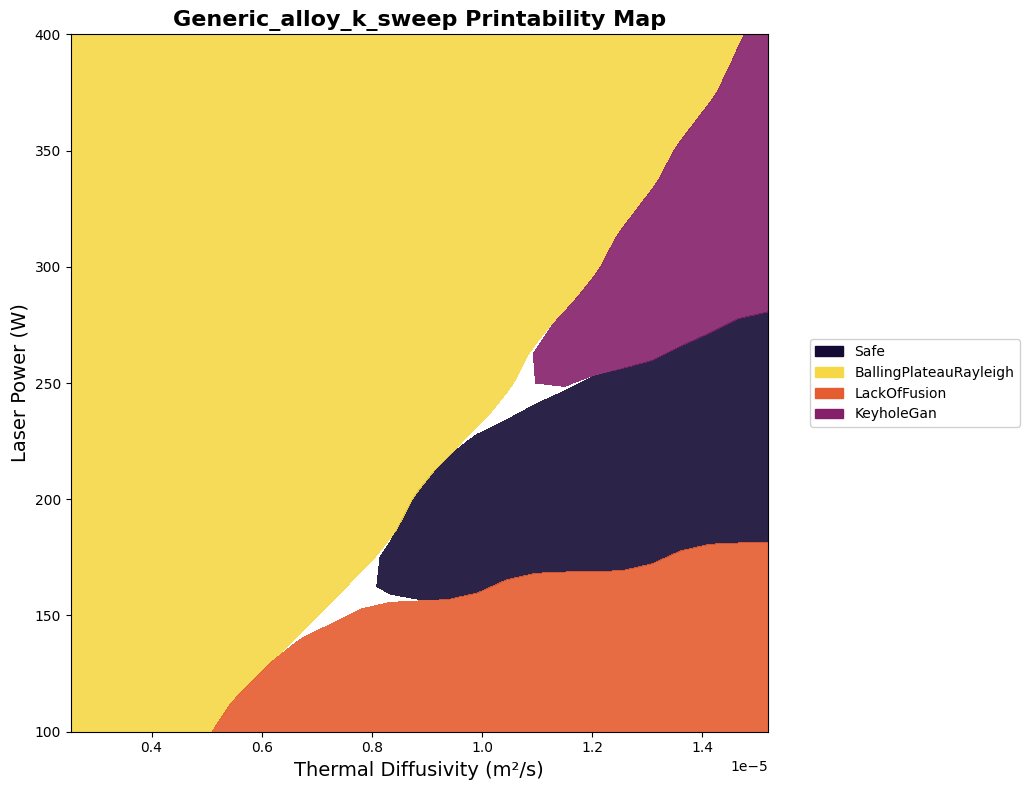

In [7]:
fig, ax = space_alloy.plot_2d(x_axis='thermal_diffusivity', y_axis='laser_power', save_path='plots/alloy_k_alpha_sweep.png')

---

## Section 4 — Unconventional Individual Defects

The `plot_individual_defects` method works seamlessly with unconventional axes too. We can break apart the defect evaluation grid from Section 2 (absorptivity vs scan speed) into individual subplots.

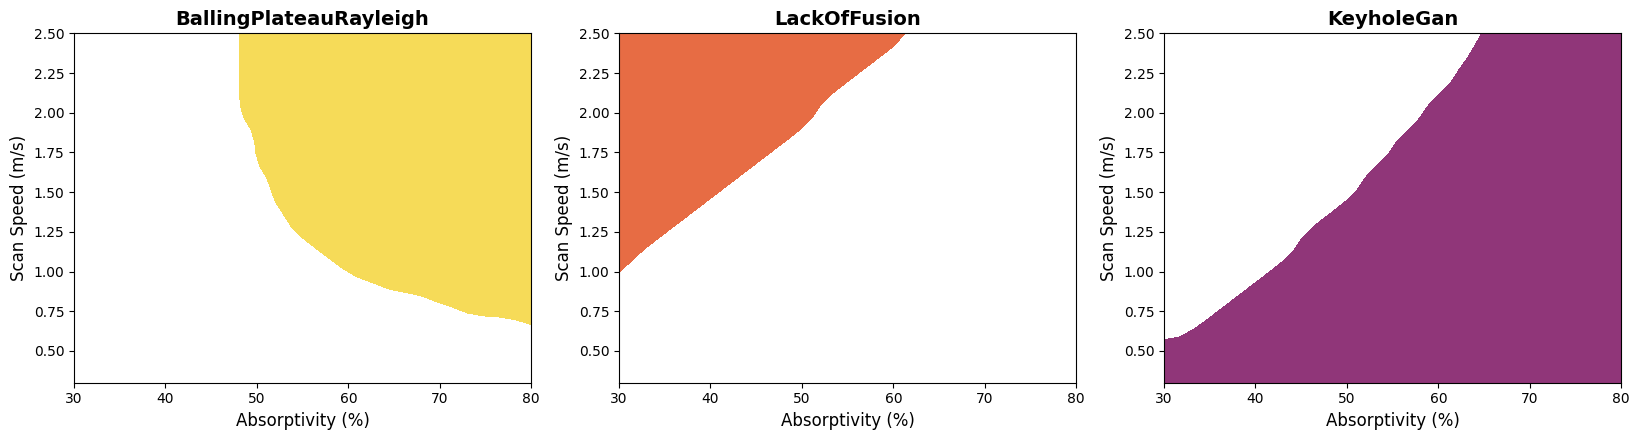

In [8]:
# Plot individual defects for the absorptivity sweep
# We use the same 'space' and 'suite' from Section 2
import matplotlib.pyplot as plt

fig, axes = space.plot_individual_defects(x_axis='absorptivity', y_axis='scan_speed')
plt.show()